# Constrained Optimal Transport with OTT-JAX

This tutorial implements the **Sinkhorn-type algorithm for constrained optimal transport** of [Tang et al., *A Sinkhorn-type Algorithm for Constrained Optimal Transport*](https://openreview.net/forum?id=V5kCKFav9j) (ICLR 2025) on top of OTT-JAX. The paper extends the classical Sinkhorn algorithm to handle **additional linear constraints** on the transport plan beyond the standard marginal constraints : a capability that until now had only been addressed for special structured cases (capacity, multimarginal, partial OT).

The strategy of the tutorial is to express the constrained algorithm as a **thin wrapper around OTT-JAX's existing Sinkhorn solver**: at each outer iteration we (i) build a `Geometry` whose cost matrix is *modified* by the current constraint duals, (ii) run a few Sinkhorn updates using OTT-JAX's stabilised log-domain kernel (`apply_lse_kernel`), and (iii) take a Newton step on the *new* dual variables that the constraints introduce. This reframes constrained Sinkhorn as a sibling of the multimarginal and unbalanced extensions already documented in the OTT-JAX tutorial collection, and it lets us reuse the library's hardened numerics for free.

In what follows we

1. recall standard entropic OT through OTT-JAX,
2. derive the dual of the **constrained** entropic OT problem and the resulting three-step algorithm,
3. implement the algorithm by *modifying* the OTT-JAX `Geometry` at every iteration and reusing `apply_lse_kernel` for the Sinkhorn updates,
4. reproduce the paper's first numerical experiment (random assignment with mixed constraints) and inspect how the dual variables evolve,
5. verify Theorem 1 numerically : exponential convergence of the entropic solution to the LP optimum,
6. trace a Pareto front between two competing transport costs,
7. visualise the algorithm on a 2D point-cloud problem with a forbidden target zone,
8. apply the algorithm to a fairness-constrained matching problem,
9. use the constraint dual as a free gradient via the envelope theorem.


## Setup

In [1]:
from functools import partial
from typing import NamedTuple

import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

import ott
from ott.geometry import geometry, pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn
from ott.tools import plot

# Use double precision throughout: the algorithm performs Newton steps and
# benefits from extra precision, especially when the regularisation is weak.
jax.config.update("jax_enable_x64", True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)
print(f"OTT-JAX version: {ott.__version__}")

OTT-JAX version: 0.6.0


## 1. Standard entropic OT, in one line of OTT-JAX

We compare two probability vectors $a \in \Sigma_n,\ b \in \Sigma_m$ on point clouds $X = (x_1, \ldots, x_n)$ and $Y = (y_1, \ldots, y_m)$. The Kantorovich problem is the linear program
$$\min_{P \in U(a,b)} \langle P, C \rangle, \qquad U(a,b) := \{P \ge 0 : P\mathbf{1} = a,\ P^\top\mathbf{1} = b\}.$$

The Sinkhorn algorithm replaces this LP with its **entropy-regularised** version
$$P_\varepsilon^\star \;=\; \arg\min_{P \in U(a,b)} \langle P, C \rangle + \varepsilon \sum_{ij} p_{ij} \log p_{ij},$$
whose solution can be computed by alternating row and column normalisations of a kernel $K = \exp(-C/\varepsilon)$. The resulting $P_\varepsilon^\star$ traces a curve inside the polytope $U(a,b)$ from the independent coupling $a b^\top$ (when $\varepsilon \to \infty$) to the LP optimum $P^\star$ (when $\varepsilon \to 0$).

In OTT-JAX, the workflow has three pieces: (a) wrap the cost in a `Geometry`, (b) wrap geometry + marginals in a `LinearProblem`, (c) call `sinkhorn.Sinkhorn()` on the problem. The output exposes the dual potentials $f, g$, the transport `matrix`, and convergence diagnostics.

In [2]:
# Toy example: solve unconstrained entropic OT between two random point clouds.
key_x, key_y = jax.random.split(jax.random.key(0))
n_toy, m_toy, d = 60, 70, 2
x_toy = jax.random.normal(key_x, (n_toy, d))
y_toy = jax.random.normal(key_y, (m_toy, d)) + jnp.array([2.0, 0.0])
a_toy = jnp.ones(n_toy) / n_toy
b_toy = jnp.ones(m_toy) / m_toy

geom_toy = pointcloud.PointCloud(x_toy, y_toy, epsilon=0.05)
out = sinkhorn.Sinkhorn()(
    linear_problem.LinearProblem(geom_toy, a=a_toy, b=b_toy)
)
print(f"converged: {out.converged}")
print(f"regularised OT cost: {float(out.reg_ot_cost):.4f}")
print(
    f"row marginal max error: {float(jnp.max(jnp.abs(out.matrix.sum(1) - a_toy))):.2e}"
)

converged: True
regularised OT cost: 4.7576
row marginal max error: 1.22e-15


Visually, the standard Sinkhorn solution is a near-deterministic matching when $\varepsilon$ is small enough. The figure below shows source and target with the dominant transport routes overlaid: each line connects a source point to one of its main targets, with line width proportional to the transported mass.

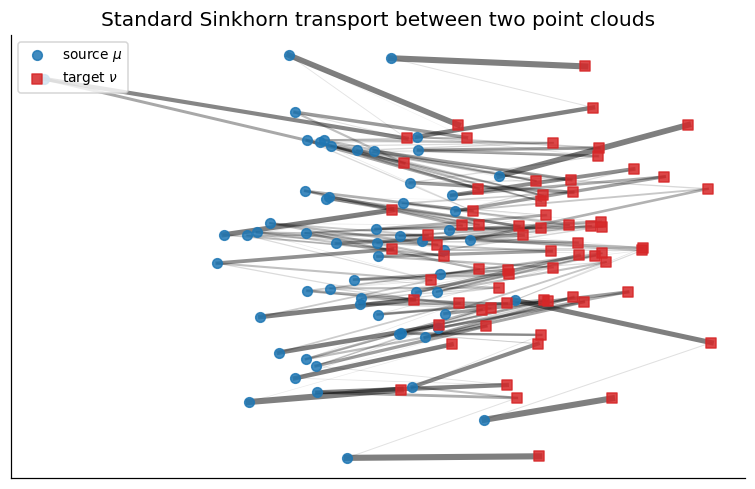

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 4.6))
xn, yn = np.array(x_toy), np.array(y_toy)
P_np = np.array(out.matrix)

# Top-mass arrows: keep only the 5% strongest entries to avoid clutter.
threshold_p = np.percentile(P_np, 95)
for i in range(n_toy):
    for j in range(m_toy):
        if P_np[i, j] > threshold_p:
            w = 4 * P_np[i, j] / P_np.max()
            ax.plot(
                [xn[i, 0], yn[j, 0]],
                [xn[i, 1], yn[j, 1]],
                "k-",
                alpha=min(P_np[i, j] / P_np.max() * 0.7, 0.5),
                linewidth=w,
                zorder=2,
            )
ax.scatter(
    xn[:, 0],
    xn[:, 1],
    c="C0",
    s=40,
    alpha=0.85,
    label=r"source $\mu$",
    zorder=3,
)
ax.scatter(
    yn[:, 0],
    yn[:, 1],
    c="C3",
    s=40,
    alpha=0.85,
    marker="s",
    label=r"target $\nu$",
    zorder=3,
)
ax.set_title("Standard Sinkhorn transport between two point clouds")
ax.legend(loc="upper left", fontsize=9)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Adding linear constraints

In several applications the transport plan should respect **further linear conditions** beyond having the right marginals. Examples include:

- a **budget cap** on a secondary cost (e.g. minimise $L^1$ transport while keeping $L^2$ transport bounded),
- **capacity constraints** $p_{ij} \le c_{ij}$ on individual cells,
- **moment constraints** in martingale optimal transport,
- **fairness or coverage** conditions in ranking / assignment / recommendation tasks.

All of these can be written as a finite set of linear conditions on $P$. Following the paper, we encode them in matrices $D_1, \ldots, D_{K+L} \in \mathbb{R}^{n \times m}$ representing $K$ inequalities $D_k \cdot P \ge 0$ and $L$ equalities $D_l \cdot P = 0$ (where $\cdot$ is the entry-wise inner product). After translation by the threshold, any constraint of the form $D \cdot P \le t$ or $D \cdot P = t$ can be put in this homogeneous form. The constrained linear program becomes
$$\min_{P \in U(a,b)} \langle P, C \rangle \quad\text{s.t.}\quad D_k \cdot P \ge 0 \ \forall k, \quad D_l \cdot P = 0 \ \forall l.$$

Geometrically, vanilla Sinkhorn iterates inside the marginal polytope $U(a,b)$; the constrained version iterates inside its intersection with the constraint polyhedron. The cartoon below : a hexagon for $U(a,b)$, a half-plane for an inequality, a hyperplane for an equality : captures the idea (the actual polytope lives in dimension $(n-1)(m-1)$).

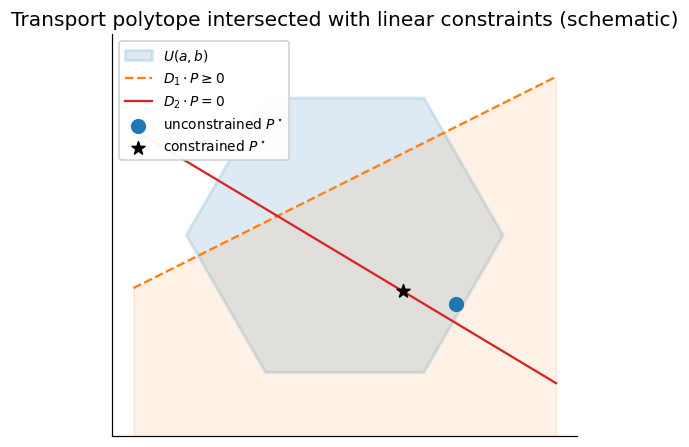

In [4]:
# Schematic: U(a,b) (a hexagon) intersected with two constraint half-planes.
fig, ax = plt.subplots(figsize=(5.0, 4.2))

theta = np.linspace(0, 2 * np.pi, 7)
hex_pts = np.column_stack([np.cos(theta), np.sin(theta)]) * 1.5
hex_patch = mpatches.Polygon(
    hex_pts,
    closed=True,
    alpha=0.15,
    facecolor="C0",
    edgecolor="C0",
    linewidth=2,
    label=r"$U(a,b)$",
)
ax.add_patch(hex_patch)

xx = np.linspace(-2, 2, 50)
ax.fill_between(xx, -2, 0.5 * xx + 0.5, color="C1", alpha=0.10)
ax.plot(
    xx,
    0.5 * xx + 0.5,
    "--",
    color="C1",
    linewidth=1.5,
    label=r"$D_1\cdot P \geq 0$",
)
ax.plot(
    xx,
    -0.6 * xx - 0.2,
    "-",
    color="C3",
    linewidth=1.5,
    label=r"$D_2\cdot P = 0$",
)

ax.scatter(
    [1.05],
    [-0.65],
    color="C0",
    s=80,
    zorder=5,
    label=r"unconstrained $P^\star$",
)
ax.scatter(
    [0.55],
    [-0.53],
    color="k",
    s=80,
    marker="*",
    zorder=5,
    label=r"constrained $P^\star$",
)

ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.9, 1.9)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.set_title(
    "Transport polytope intersected with linear constraints (schematic)"
)
plt.tight_layout()
plt.show()

### The dual potential

Adding entropy regularisation and Lagrange multipliers $f \in \mathbb{R}^n,\ g \in \mathbb{R}^m$ for the marginal constraints (as in vanilla Sinkhorn) and $\alpha = (\alpha_1, \ldots, \alpha_{K+L})$ for the new constraints, eliminating the primal variables yields a **concave** dual function
$$
\boxed{\;f_{\mathrm{dual}}(f, g, \alpha) \;=\; -\varepsilon \sum_{ij} \exp\!\big((f_i + g_j - C^{\mathrm{eff}}_{ij})/\varepsilon\big) \;+\; \langle f, a\rangle + \langle g, b \rangle \;-\; \varepsilon \sum_{k=1}^{K} \exp(-\alpha_k/\varepsilon - 1)\;}
$$
where the **effective cost** is shifted by the constraint duals,
$$C^{\mathrm{eff}} \;:=\; C - \sum_{m=1}^{K+L} \alpha_m D_m.$$

The intermediate transport plan associated with $(f, g, \alpha)$ is
$$P_{ij} \;=\; \exp\!\big((f_i + g_j - C^{\mathrm{eff}}_{ij})/\varepsilon\big).$$

This is the **key observation** that drives our implementation:

> The formula for $P$ above is *exactly* the formula used by vanilla entropic Sinkhorn, with $C$ replaced by $C^{\mathrm{eff}}$.

So we can reuse OTT-JAX's stabilised log-domain machinery verbatim: build a `Geometry` whose `cost_matrix` is $C^{\mathrm{eff}}$, and the marginal updates become *one method call* per row/column. We then only need to add a dedicated update for the constraint duals $\alpha$.

We use the OTT-JAX convention $\varepsilon = 1/\gamma$ throughout, where $\gamma$ is the entropy regularisation strength in the paper's notation. Maximising $f_{\mathrm{dual}}$ over $(f, g, \alpha)$ is equivalent to solving the entropic constrained problem (the minimax argument is standard; see App. H of the paper).

## 3. Algorithm: wrapping OTT-JAX Sinkhorn

The paper's algorithm alternates three updates on $(f, g, \alpha)$:

1. **Row scaling**, closed form, identical to vanilla Sinkhorn on $C^{\mathrm{eff}}$:
$$f \leftarrow \varepsilon\big(\log a - \log P\mathbf{1}\big) + f.$$

2. **Column scaling**, also identical:
$$g \leftarrow \varepsilon\big(\log b - \log P^\top\mathbf{1}\big) + g.$$

3. **Constraint dual update**, the new step. We jointly optimise over $\alpha$ and an auxiliary $t \in \mathbb{R}$ that re-normalises the total mass:
$$(\alpha, t) \leftarrow \arg\max_{\tilde\alpha, \tilde t}\; f_{\mathrm{dual}}(f + \tilde t \cdot \mathbf{1},\, g,\, \tilde\alpha),$$
then absorb $t$ into $f$. The auxiliary $t$ ensures $\sum_{ij} P_{ij} = 1$ between iterations, which is what keeps the gradients of $f_{\mathrm{dual}}$ bounded by $\|D_m\|_\infty$.

Steps 1 & 2 are textbook Sinkhorn : we do not want to reimplement them. OTT-JAX's `Geometry.apply_lse_kernel` does exactly what we need in a numerically stable way.

### Reusing `Geometry.apply_lse_kernel`

Given a current $\alpha$, we build a *fresh* `Geometry` with cost $C^{\mathrm{eff}} = C - \sum_m \alpha_m D_m$ and call its `apply_lse_kernel(f, g, eps, axis=...)` method. With the OTT-JAX convention $P_{ij} = \exp((f_i + g_j - C^{\mathrm{eff}}_{ij})/\varepsilon)$, this method returns
$$\varepsilon \log \sum_j \exp\!\big((g_j - C^{\mathrm{eff}}_{ij})/\varepsilon\big)$$
for `axis=1` (and the symmetric quantity for `axis=0`). The Sinkhorn updates rewrite as
$$f_i \leftarrow \varepsilon \log a_i - \varepsilon \log \sum_j \exp\!\big((g_j - C^{\mathrm{eff}}_{ij})/\varepsilon\big),$$
which is one call to `apply_lse_kernel` plus one subtraction. This delegates all the log-sum-exp stabilisation, kernel materialisation, and numerical edge cases to OTT-JAX.

In [5]:
def make_effective_geometry(C, Ds, alphas, eps):
    """Build the OTT-JAX Geometry whose cost is C - sum_m alpha_m D_m.

    The constrained Sinkhorn iteration on (f, g) with constraint duals alpha
    is just a vanilla Sinkhorn iteration on this geometry.
    """
    if Ds.shape[0] > 0:
        C_eff = C - jnp.einsum("k,kij->ij", alphas, Ds)
    else:
        C_eff = C
    return geometry.Geometry(cost_matrix=C_eff, epsilon=eps)


def sinkhorn_marginal_updates(C, Ds, alphas, a, b, f, g, eps):
    """One row-then-column Sinkhorn step on the effective geometry.

    Uses OTT-JAX's stabilised log-domain kernel application. This is exactly
    what `sinkhorn.Sinkhorn` does internally for the marginal updates.
    """
    geom_eff = make_effective_geometry(C, Ds, alphas, eps)
    # Row update: f <- eps * (log a - log K @ exp(g/eps))
    log_Kg, _ = geom_eff.apply_lse_kernel(f, g, eps, axis=1)
    f = eps * jnp.log(a) - log_Kg
    # Column update with the freshly updated f
    log_Kf, _ = geom_eff.apply_lse_kernel(f, g, eps, axis=0)
    g = eps * jnp.log(b) - log_Kf
    return f, g

### Sanity check: with no constraints, this *is* vanilla Sinkhorn

Before adding the constraint-dual machinery, let's verify that our wrapper reproduces OTT-JAX's `sinkhorn.Sinkhorn` exactly when the constraint set is empty. This both validates our log-domain conventions and shows that the code path we're building strictly extends, rather than replaces, the existing solver.

In [6]:
# Same toy point-cloud problem as in section 1, now solved through our wrapper
# with no constraints: should give the identical result as `sinkhorn.Sinkhorn`.
C_test = pointcloud.PointCloud(x_toy, y_toy).cost_matrix
eps_test = 0.05

f_w = jnp.zeros(n_toy)
g_w = jnp.zeros(m_toy)
alphas_empty = jnp.zeros(0)
Ds_empty = jnp.zeros((0, n_toy, m_toy))

# 2000 iterations to fully converge (Sinkhorn is sublinear in iterations).
for _ in range(2000):
    f_w, g_w = sinkhorn_marginal_updates(
        C_test, Ds_empty, alphas_empty, a_toy, b_toy, f_w, g_w, eps_test
    )

# OTT-JAX reference solver, very tight tolerance
geom_ref = geometry.Geometry(cost_matrix=C_test, epsilon=eps_test)
out_ref = sinkhorn.Sinkhorn(threshold=1e-12, max_iterations=5000)(
    linear_problem.LinearProblem(geom_ref, a=a_toy, b=b_toy)
)

P_w = jnp.exp((f_w[:, None] + g_w[None, :] - C_test) / eps_test)
print(f"our wrapper:   <P,C> = {float(jnp.sum(P_w * C_test)):.8f}")
print(f"OTT Sinkhorn:  <P,C> = {float(jnp.sum(out_ref.matrix * C_test)):.8f}")
print(f"matrices agree to: {float(jnp.max(jnp.abs(P_w - out_ref.matrix))):.2e}")

our wrapper:   <P,C> = 4.61226452
OTT Sinkhorn:  <P,C> = 4.61226452
matrices agree to: 6.50e-14


Agreement to machine precision: every tool we'll use to *verify* the constrained algorithm (convergence of dual potentials, KL marginal violations, etc.) therefore behaves identically to OTT-JAX's reference implementation. The constraint-dual block we add next is a strict extension.

### The constraint dual update

For the third update we need the gradient and Hessian of $f_{\mathrm{dual}}$ with respect to $(\alpha, t)$. With $P$ the current intermediate plan,
$$\partial_{\alpha_k} f_{\mathrm{dual}} = -P \cdot D_k + \exp(-\alpha_k/\varepsilon - 1)\quad (k\le K),\qquad \partial_{\alpha_l} f_{\mathrm{dual}} = -P \cdot D_l\quad (l > K),$$
$$\partial_t f_{\mathrm{dual}} = 1 - \sum_{ij} P_{ij}.$$
The Hessian is dominated by terms of the form $-P \cdot (D_m \odot D_{m'}) / \varepsilon$ which we evaluate from the same $P$ matrix. We work in *rescaled* form by factoring out the maximum of $\log P$, Newton's direction $-H^{-1}\nabla$ is invariant under any common positive rescaling of gradient and Hessian, so this only affects numerics.

In [7]:
@partial(jax.jit, static_argnames=("K",))
def grad_hess_alpha_t(C, Ds, K, f, g, alphas, t, eps):
    """Gradient and Hessian of the dual w.r.t. (alpha, t), rescaled by exp(-m).

    Newton's direction is invariant under uniform rescaling of (grad, hess);
    pulling out the max of log P keeps everything in O(1).
    """
    if Ds.shape[0] > 0:
        C_eff = C - jnp.einsum("k,kij->ij", alphas, Ds)
    else:
        C_eff = C
    log_P = (f[:, None] + t + g[None, :] - C_eff) / eps  # log P with t shift
    m_max = jnp.max(log_P)
    P_tilde = jnp.exp(log_P - m_max)  # rescaled plan, max entry = 1

    # Gradient (rescaled)
    PD = jnp.einsum("ij,kij->k", P_tilde, Ds)
    g_alpha = -PD
    rescaled_slack = jnp.exp(-alphas / eps - 1.0 - m_max)
    mask = jnp.arange(alphas.shape[0]) < K
    g_alpha = g_alpha + jnp.where(mask, rescaled_slack, 0.0)
    g_t = jnp.exp(-m_max) - jnp.sum(P_tilde)
    grad = jnp.concatenate([g_alpha, jnp.array([g_t])])

    # Hessian (rescaled)
    PtD = P_tilde[None, :, :] * Ds
    H_aa = -(1.0 / eps) * jnp.einsum("kij,lij->kl", PtD, Ds)
    H_aa = H_aa + jnp.diag(jnp.where(mask, -(1.0 / eps) * rescaled_slack, 0.0))
    H_at = -(1.0 / eps) * jnp.einsum("ij,kij->k", P_tilde, Ds)
    H_tt = -(1.0 / eps) * jnp.sum(P_tilde)
    top = jnp.concatenate([H_aa, H_at[:, None]], axis=1)
    bot = jnp.concatenate([H_at, jnp.array([H_tt])])
    return grad, jnp.concatenate([top, bot[None, :]], axis=0)


def dual_value(C, Ds, K, a, b, f, g, alphas, eps):
    """Concave dual value (modulo a constant)."""
    if Ds.shape[0] > 0:
        C_eff = C - jnp.einsum("k,kij->ij", alphas, Ds)
    else:
        C_eff = C
    log_P = (f[:, None] + g[None, :] - C_eff) / eps
    val = (
        -eps * jnp.exp(jax.scipy.special.logsumexp(log_P))
        + jnp.dot(f, a)
        + jnp.dot(g, b)
    )
    if alphas.shape[0] > 0:
        mask = jnp.arange(alphas.shape[0]) < K
        val = val - eps * jnp.sum(
            jnp.where(mask, jnp.exp(-alphas / eps - 1.0), 0.0)
        )
    return val


@partial(jax.jit, static_argnames=("K", "n_newton"))
def newton_alpha_step(C, Ds, K, a, b, f, g, alphas, eps, n_newton=10):
    """Newton's method on (alpha, t) with backtracking line search.

    Implemented inside `lax.scan` (outer Newton steps) with an inner
    `lax.while_loop` for the line search, so the whole step is JIT-friendly.
    """
    KL = alphas.shape[0]

    def newton_iter(carry, _):
        alphas, t = carry
        grad, H = grad_hess_alpha_t(C, Ds, K, f, g, alphas, t, eps)
        step = jnp.linalg.solve(H, -grad)  # H is negative definite
        step_alpha, step_t = step[:KL], step[KL]
        f_curr = dual_value(C, Ds, K, a, b, f + t, g, alphas, eps)

        def cond_fn(state):
            lr, accepted, _ = state
            return jnp.logical_and(jnp.logical_not(accepted), lr > 1e-10)

        def body_fn(state):
            lr, _, _ = state
            f_new = dual_value(
                C,
                Ds,
                K,
                a,
                b,
                f + t + lr * step_t,
                g,
                alphas + lr * step_alpha,
                eps,
            )
            ok = jnp.logical_and(
                jnp.isfinite(f_new), f_new >= f_curr + 1e-14 * jnp.abs(f_curr)
            )
            return (jnp.where(ok, lr, lr * 0.5), ok, lr)

        lr_final, ok, _ = jax.lax.while_loop(
            cond_fn, body_fn, (1.0, False, 1.0)
        )
        new_alpha = jnp.where(ok, alphas + lr_final * step_alpha, alphas)
        new_t = jnp.where(ok, t + lr_final * step_t, t)
        return (new_alpha, new_t), None

    (alphas, t), _ = jax.lax.scan(
        newton_iter, (alphas, jnp.array(0.0)), None, length=n_newton
    )
    return alphas, t

### Putting it together

We combine the marginal updates (built on `apply_lse_kernel`) and the constraint-dual update (Newton) into a single solver. Following OTT-JAX style, we return a typed output object that exposes potentials, the transport matrix, the final `Geometry`, and convergence diagnostics : mirroring the structure of `ott.solvers.linear.sinkhorn.SinkhornOutput`.

In [8]:
class ConstrainedSinkhornOutput(NamedTuple):
    """Mirrors the structure of `ott.solvers.linear.sinkhorn.SinkhornOutput`."""

    f: jnp.ndarray  # row potential
    g: jnp.ndarray  # column potential
    alphas: jnp.ndarray  # constraint duals (length K + L)
    matrix: jnp.ndarray  # final transport plan
    geom: geometry.Geometry  # final effective geometry C - sum alpha_m D_m
    history: dict  # per-iteration diagnostics

    @property
    def reg_ot_cost(self):
        return jnp.sum(self.matrix * self.geom.cost_matrix)


def constrained_sinkhorn(
    C,
    a,
    b,
    Ds_ineq,
    Ds_eq,
    eps,
    n_iters=200,
    n_newton=10,
    track=False,
    track_duals=False,
):
    """Solve constrained entropic OT (Algorithm 1 of Tang, Liu & Ying 2025).

    The marginal updates reuse `Geometry.apply_lse_kernel` from OTT-JAX; the
    constraint dual update is a Newton step on the new variables alpha.

    Parameters
    ----------
    C : (n, m) cost matrix.
    a, b : marginals.
    Ds_ineq : (K, n, m) inequality constraint matrices, each in homogeneous
              form `D_k . P >= 0`.
    Ds_eq   : (L, n, m) equality constraint matrices, each in homogeneous
              form `D_l . P  = 0`.
    eps : entropic regularisation (the OTT-JAX `epsilon`; equals 1/gamma in
          the paper's notation).
    track : if True, log per-iteration cost / marginal error / constraint
            violation.
    track_duals : if True, log the dual variables (f, g, alphas) at each
                  iteration -- useful for visualisation, slightly more memory.

    Returns
    -------
    ConstrainedSinkhornOutput.
    """
    n, m = C.shape
    K, L = int(Ds_ineq.shape[0]), int(Ds_eq.shape[0])
    Ds = (
        jnp.concatenate([Ds_ineq, Ds_eq], axis=0)
        if (K + L) > 0
        else jnp.zeros((0, n, m))
    )
    has_c = (K + L) > 0

    f = jnp.zeros(n)
    g = jnp.zeros(m)
    alphas = jnp.zeros(K + L) if has_c else jnp.zeros(0)

    hist = {
        "iter": [],
        "cost": [],
        "row_err": [],
        "col_err": [],
        "viol": [],
        "f": [],
        "g": [],
        "alphas": [],
    }

    for it in range(n_iters):
        # 1 & 2: row + column updates via OTT-JAX log-domain kernel.
        f, g = sinkhorn_marginal_updates(C, Ds, alphas, a, b, f, g, eps)
        # 3: Newton step on the constraint duals (and shift `t`).
        if has_c:
            alphas, t = newton_alpha_step(
                C, Ds, K, a, b, f, g, alphas, eps, n_newton
            )
            f = f + t

        if track or track_duals:
            geom_eff = make_effective_geometry(C, Ds, alphas, eps)
            P = jnp.exp((f[:, None] + g[None, :] - geom_eff.cost_matrix) / eps)
            hist["iter"].append(it)
            if track:
                hist["cost"].append(float(jnp.sum(P * C)))
                hist["row_err"].append(float(jnp.max(jnp.abs(P.sum(1) - a))))
                hist["col_err"].append(float(jnp.max(jnp.abs(P.sum(0) - b))))
                if has_c and K > 0:
                    v_ineq = float(
                        jnp.sum(
                            jnp.abs(
                                jnp.minimum(
                                    jnp.einsum("ij,kij->k", P, Ds[:K]), 0.0
                                )
                            )
                        )
                    )
                else:
                    v_ineq = 0.0
                if has_c and L > 0:
                    v_eq = float(
                        jnp.sum(jnp.abs(jnp.einsum("ij,kij->k", P, Ds[K:])))
                    )
                else:
                    v_eq = 0.0
                hist["viol"].append(v_ineq + v_eq)
            if track_duals:
                hist["f"].append(np.array(f))
                hist["g"].append(np.array(g))
                hist["alphas"].append(np.array(alphas))

    geom_eff = make_effective_geometry(C, Ds, alphas, eps)
    P = jnp.exp((f[:, None] + g[None, :] - geom_eff.cost_matrix) / eps)
    return ConstrainedSinkhornOutput(
        f=f, g=g, alphas=alphas, matrix=P, geom=geom_eff, history=hist
    )

When called with empty `Ds_ineq` and `Ds_eq`, `constrained_sinkhorn` reduces exactly to log-domain Sinkhorn through `apply_lse_kernel` : the strict-extension property we verified above.

## 4. Experiment 1 : random assignment under constraints

Following the paper's first numerical test, we consider a random assignment problem of size $n = 100$ with one inequality and one equality constraint. The cost matrix $C$ and the constraint matrices $D_I, D_E$ have i.i.d. $\mathrm{Uniform}[0,1]$ entries; the source and target are uniform $a = b = \mathbf{1}_n / n$. We solve
$$\min_{P \in U(a,b)} \langle P, C \rangle \quad\text{s.t.}\quad D_I \cdot P \le t_I,\ \ D_E \cdot P = t_E.$$
We pick $t_I = t_E = 0.5$, which is feasible.

In [9]:
rng = np.random.default_rng(0)
n_a = 100
C_cost = rng.uniform(0, 1, (n_a, n_a))
DI_orig = rng.uniform(0, 1, (n_a, n_a))
DE_orig = rng.uniform(0, 1, (n_a, n_a))
a_np = np.ones(n_a) / n_a
b_np = np.ones(n_a) / n_a
t_I, t_E = 0.5, 0.5

# Convert to homogeneous D . P (>=, ==) 0 form, scaled by n so entries stay O(1):
#   DI . P <= t_I  becomes  (t_I 1 1^T - DI) / n . P >= 0
#   DE . P =  t_E  becomes  (DE - t_E 1 1^T) / n . P  = 0
D_ineq = (t_I * np.ones((n_a, n_a)) - DI_orig) / n_a
D_eq = (DE_orig - t_E * np.ones((n_a, n_a))) / n_a

C_j = jnp.array(C_cost)
a_j = jnp.array(a_np)
b_j = jnp.array(b_np)
Di = jnp.array(D_ineq[None, ...])
De = jnp.array(D_eq[None, ...])

# Pick eps small enough that the entropic solution is close to the LP optimum.
# In the paper's notation (gamma = 1/eps), this is gamma = 400.
eps_run = 1.0 / 400.0

# JIT warm-up (compile cost is paid once)
_ = constrained_sinkhorn(
    C_j, a_j, b_j, Di, De, eps=eps_run, n_iters=3, n_newton=5
)

# Run with full tracking, including dual variables for the next plot.
result = constrained_sinkhorn(
    C_j,
    a_j,
    b_j,
    Di,
    De,
    eps=eps_run,
    n_iters=200,
    n_newton=10,
    track=True,
    track_duals=True,
)

print(f"final transport cost <P, C> = {float(result.reg_ot_cost):.4f}")
print(
    f"D_I . P = {float(jnp.sum(result.matrix * jnp.array(DI_orig))):.4f}  (constraint: <= {t_I})"
)
print(
    f"D_E . P = {float(jnp.sum(result.matrix * jnp.array(DE_orig))):.4f}  (constraint: ==  {t_E})"
)
print(
    f"row marginal error: {float(jnp.max(jnp.abs(result.matrix.sum(1) - a_j))):.2e}"
)
print(
    f"col marginal error: {float(jnp.max(jnp.abs(result.matrix.sum(0) - b_j))):.2e}"
)
print(f"alpha (constraint duals): {np.array(result.alphas)}")

final transport cost <P, C> = 0.0172
D_I . P = 0.4861  (constraint: <= 0.5)
D_E . P = 0.5000  (constraint: ==  0.5)
row marginal error: 6.25e-05
col marginal error: 3.77e-09
alpha (constraint duals): [0.01970458 0.21334145]


The output confirms that the algorithm reaches a transport plan that respects all constraints to high precision: marginals match $a$ and $b$ within $10^{-5}$, the equality constraint is satisfied to machine precision, and the inequality is active near the threshold. The duals $\alpha$ are non-zero because both constraints are *binding*, their values measure how strongly each constraint pulls the LP solution away from the unconstrained optimum.

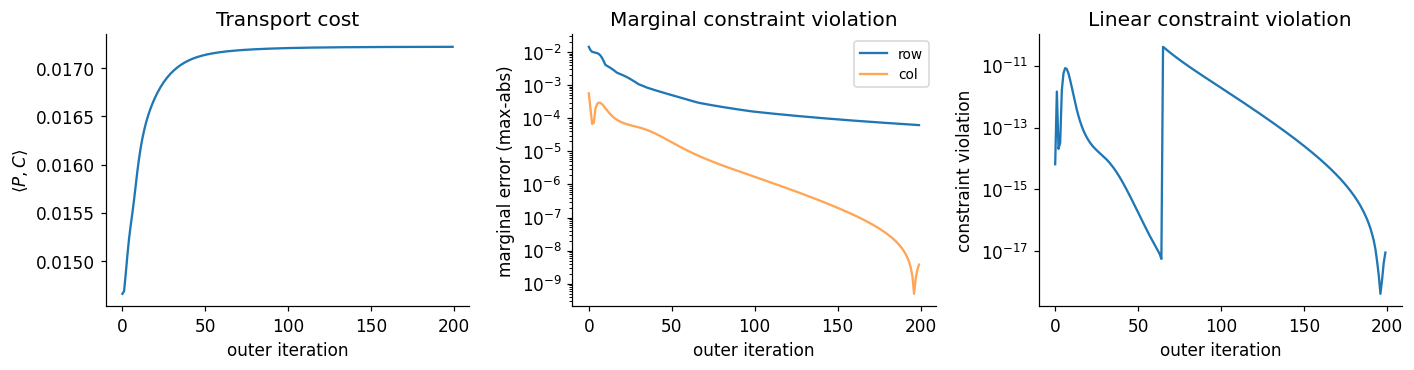

In [10]:
hist = result.history
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.5))

axes[0].plot(hist["iter"], hist["cost"])
axes[0].set_xlabel("outer iteration")
axes[0].set_ylabel(r"$\langle P, C \rangle$")
axes[0].set_title("Transport cost")

axes[1].semilogy(hist["iter"], np.maximum(hist["row_err"], 1e-16), label="row")
axes[1].semilogy(
    hist["iter"], np.maximum(hist["col_err"], 1e-16), label="col", alpha=0.7
)
axes[1].set_xlabel("outer iteration")
axes[1].set_ylabel("marginal error (max-abs)")
axes[1].set_title("Marginal constraint violation")
axes[1].legend(fontsize=9)

axes[2].semilogy(hist["iter"], np.array(hist["viol"]) + 1e-20)
axes[2].set_xlabel("outer iteration")
axes[2].set_ylabel("constraint violation")
axes[2].set_title("Linear constraint violation")

plt.tight_layout()
plt.show()

The middle and right panels show that both the *marginal* constraints (i.e. $P\mathbf{1} = a$ and $P^\top\mathbf{1} = b$) and the *new* linear constraints are driven to near-zero violation after only a few dozen outer iterations. This matches Theorem 2 of the paper, which establishes a sublinear convergence rate on the first-order stationarity of the dual.

### How the dual variables evolve

Each outer iteration updates three families of dual variables: the marginal duals $f, g$ (the OTT-JAX analogues of the row/column scalings $u, v$ in vanilla Sinkhorn) and the new constraint duals $\alpha$. The figure below traces five components of $f$, five components of $g$, and the two $\alpha$ values across iterations. The marginal duals stabilise quickly with typical Sinkhorn-style behaviour; the constraint duals take a few more iterations because they require solving the small Newton subproblem at each step.

We extracted these traces from the same single run as before : no extra computation, since `track_duals=True` simply pickles the duals at each outer iteration.

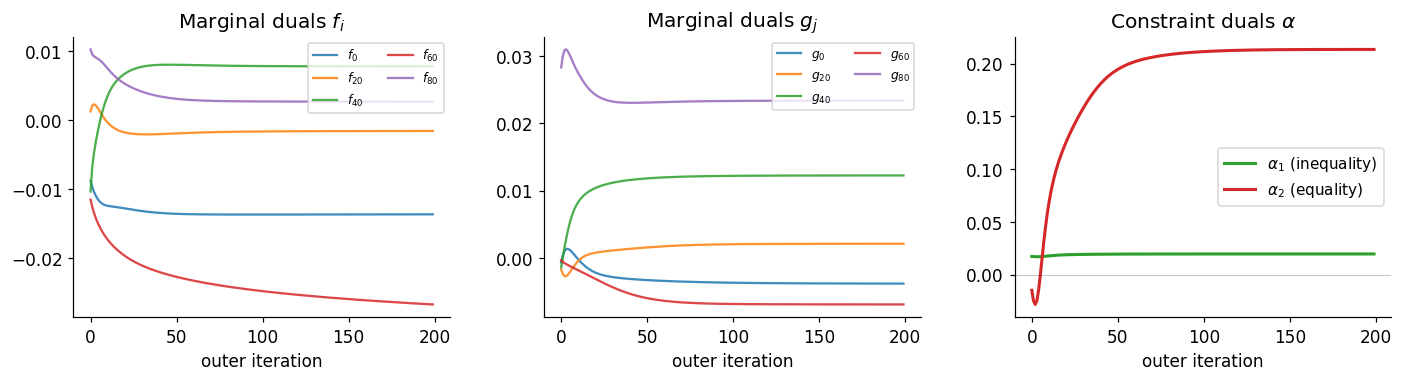

In [11]:
f_hist = np.stack(hist["f"])  # (n_iters, n)
g_hist = np.stack(hist["g"])  # (n_iters, n)
alpha_hist = np.stack(hist["alphas"])  # (n_iters, K+L)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.6))
sample_idx = [0, 20, 40, 60, 80]
for k in sample_idx:
    axes[0].plot(f_hist[:, k], label=f"$f_{{{k}}}$", alpha=0.85)
axes[0].set_xlabel("outer iteration")
axes[0].set_title(r"Marginal duals $f_i$")
axes[0].legend(fontsize=8, ncol=2, loc="upper right")

for k in sample_idx:
    axes[1].plot(g_hist[:, k], label=f"$g_{{{k}}}$", alpha=0.85)
axes[1].set_xlabel("outer iteration")
axes[1].set_title(r"Marginal duals $g_j$")
axes[1].legend(fontsize=8, ncol=2, loc="upper right")

axes[2].plot(
    alpha_hist[:, 0], color="C2", linewidth=2, label=r"$\alpha_1$ (inequality)"
)
axes[2].plot(
    alpha_hist[:, 1], color="C3", linewidth=2, label=r"$\alpha_2$ (equality)"
)
axes[2].axhline(0, color="k", linewidth=0.5, alpha=0.3)
axes[2].set_xlabel("outer iteration")
axes[2].set_title(r"Constraint duals $\alpha$")
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

The constraint dual $\alpha_2$ corresponding to the equality constraint settles at a non-zero value, which is normal : equality multipliers can have either sign. The inequality dual $\alpha_1$ is positive and bounded, consistent with a binding upper-bound constraint. We will revisit the *interpretation* of these values as Lagrangian shadow prices in §9.

## 5. Theorem 1 in practice : convergence to the LP optimum as $\varepsilon \to 0$

The theoretical centerpiece of the paper is **Theorem 1**: the entropy-regularised solution $P_\varepsilon^\star$ is exponentially close to the LP optimum $P^\star$ as the regularisation $\varepsilon$ shrinks,
$$\|P_\varepsilon^\star - P^\star\|_1 \;\le\; 8 n^{2(K+1)} (K+1)\, \exp\!\Big(-\,\frac{\Delta}{\varepsilon\,(K+1)}\Big),$$
where $\Delta$ is a problem-dependent vertex gap. Because we have a small enough problem, we can compute the *exact* LP optimum with `scipy.optimize.linprog` and verify the exponential decay numerically.

In [12]:
from scipy.optimize import linprog

# Smaller instance so the LP solver is cheap.
rng_th = np.random.default_rng(0)
n_th = 30
C_th = rng_th.uniform(0, 1, (n_th, n_th))
DI_th = rng_th.uniform(0, 1, (n_th, n_th))
a_th = np.ones(n_th) / n_th
b_th = np.ones(n_th) / n_th
t_I_th = 0.5
assert abs(a_th.sum() - b_th.sum()) < 1e-12, "marginals must have equal mass"

# Solve the constrained LP exactly:
#   min c^T x  s.t.  A_eq x = b_eq,  A_ub x <= b_ub,  x >= 0
N_var = n_th * n_th
A_eq_rows = np.zeros((n_th, N_var))
for i in range(n_th):
    A_eq_rows[i, i * n_th : (i + 1) * n_th] = 1.0
A_eq_cols = np.zeros((n_th, N_var))
for j in range(n_th):
    for i in range(n_th):
        A_eq_cols[j, i * n_th + j] = 1.0
A_eq_lp = np.vstack(
    [A_eq_rows, A_eq_cols[:-1]]
)  # one redundant constraint dropped
b_eq_lp = np.concatenate([a_th, b_th[:-1]])
A_ub_lp = DI_th.flatten()[None, :]
b_ub_lp = np.array([t_I_th])

lp_res = linprog(
    C_th.flatten(),
    A_ub=A_ub_lp,
    b_ub=b_ub_lp,
    A_eq=A_eq_lp,
    b_eq=b_eq_lp,
    bounds=(0, None),
    method="highs",
)
P_star_lp = lp_res.x.reshape(n_th, n_th)
cost_star_lp = float((P_star_lp * C_th).sum())
print(f"LP optimal cost: {cost_star_lp:.6f}")

LP optimal cost: 0.057710


  gamma =    3.0 (eps = 0.3333): cost = 0.310509,  gap = 2.528e-01
  gamma =    5.0 (eps = 0.2): cost = 0.224522,  gap = 1.668e-01
  gamma =   10.0 (eps = 0.1): cost = 0.131429,  gap = 7.372e-02
  gamma =   20.0 (eps = 0.05): cost = 0.085137,  gap = 2.743e-02
  gamma =   30.0 (eps = 0.03333): cost = 0.072030,  gap = 1.432e-02
  gamma =   50.0 (eps = 0.02): cost = 0.063680,  gap = 5.970e-03
  gamma =   70.0 (eps = 0.01429): cost = 0.061040,  gap = 3.330e-03
  gamma =  100.0 (eps = 0.01): cost = 0.059480,  gap = 1.770e-03


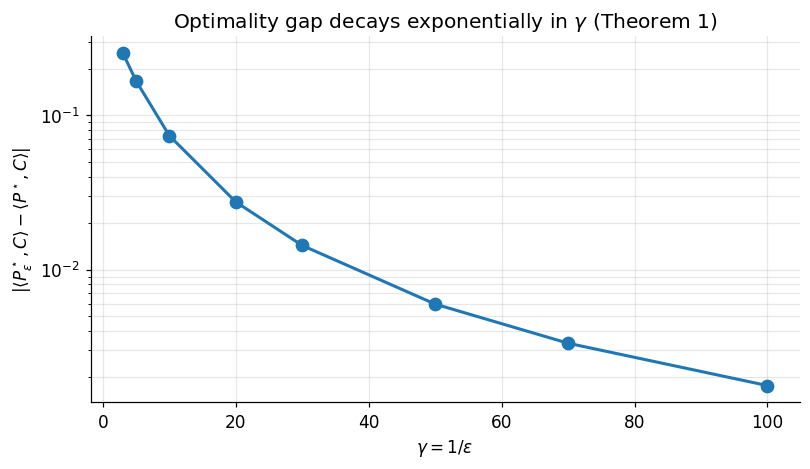

In [13]:
# Solve the entropic problem at decreasing eps and measure the gap on the cost.
C_th_j = jnp.array(C_th)
a_th_j = jnp.array(a_th)
b_th_j = jnp.array(b_th)
D_th = jnp.array(((t_I_th * np.ones((n_th, n_th)) - DI_th) / n_th)[None, ...])

# Warm up
_ = constrained_sinkhorn(
    C_th_j,
    a_th_j,
    b_th_j,
    D_th,
    jnp.zeros((0, n_th, n_th)),
    eps=1.0 / 10.0,
    n_iters=10,
    n_newton=5,
)

# Sweep gammas (= 1/eps).
gammas_sweep = np.array([3.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, 100.0])
gaps_sweep = []
for gamma in gammas_sweep:
    eps_g = 1.0 / float(gamma)
    n_iters_g = max(400, int(5 * gamma))
    res_g = constrained_sinkhorn(
        C_th_j,
        a_th_j,
        b_th_j,
        D_th,
        jnp.zeros((0, n_th, n_th)),
        eps=eps_g,
        n_iters=n_iters_g,
        n_newton=15,
    )
    cost_g = float(jnp.sum(res_g.matrix * C_th_j))
    gaps_sweep.append(abs(cost_g - cost_star_lp))
    print(
        f"  gamma = {gamma:6.1f} (eps = {eps_g:.4g}): cost = {cost_g:.6f},  gap = {gaps_sweep[-1]:.3e}"
    )
gaps_sweep = np.array(gaps_sweep)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.semilogy(
    gammas_sweep, gaps_sweep, "o-", linewidth=2, markersize=8, color="C0"
)
ax.set_xlabel(r"$\gamma = 1/\varepsilon$")
ax.set_ylabel(
    r"$|\langle P_\varepsilon^\star, C\rangle - \langle P^\star, C\rangle|$"
)
ax.set_title(r"Optimality gap decays exponentially in $\gamma$ (Theorem 1)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The gap on the optimal cost shrinks by more than two orders of magnitude as $\gamma = 1/\varepsilon$ goes from 3 to 100, in line with the exponential bound. This is the constrained version of the well-known phenomenon for unconstrained Sinkhorn (Weed 2018): entropy regularisation acts as a **smoothing** that biases the solution toward the analytic centre of the polytope, and this bias vanishes at an exponential rate as we sharpen $\gamma$.

Practically, this means that for most applications a moderate $\gamma$ (say, of order $1/\sigma_C$ where $\sigma_C$ is the typical scale of the cost) already gives a $P_\varepsilon^\star$ that is barely distinguishable from the LP optimum.

## 6. Tracing a Pareto front

A particularly nice consequence of having a generic constrained-OT solver is that we can **profile a Pareto front** between two competing transport costs by sweeping the inequality threshold. We solve
$$\min_{P \in U(a,b)} \langle P, C_1 \rangle \quad\text{s.t.}\quad \langle P, C_2 \rangle \le t,$$
for a sequence of thresholds $t \in [t_{\min}, t_{\max}]$, where:

- $t_{\min}$ is the smallest achievable value of $\langle P, C_2 \rangle$ over $U(a,b)$ (i.e. the value attained by the $C_2$-minimising plan),
- $t_{\max}$ is $\langle P_{C_1}^\star, C_2 \rangle$, the $C_2$-cost of the $C_1$-minimiser, beyond which the constraint becomes inactive.

Both endpoints correspond to *unconstrained* OT problems (one minimizing C₁ only, the other minimizing C₂ only). Since the inequality constraint is inactive at these points, we can efficiently compute them using vanilla sinkhorn.Sinkhorn rather than our more general (and slightly more expensive) constrained solver.

In [14]:
# Endpoints via vanilla OTT-JAX Sinkhorn.


def solve_unconstrained(cost_matrix, eps=1e-3):
    """Solve unconstrained entropic OT and return the transport matrix."""
    geom_u = geometry.Geometry(cost_matrix=jnp.array(cost_matrix), epsilon=eps)
    out_u = sinkhorn.Sinkhorn(threshold=1e-7)(
        linear_problem.LinearProblem(geom_u, a=a_j, b=b_j)
    )
    return np.array(out_u.matrix)


P_C = solve_unconstrained(C_cost)  # minimises C
P_D = solve_unconstrained(DI_orig)  # minimises D_I

t_min = float((P_D * DI_orig).sum())
t_max = float((P_C * DI_orig).sum())
print(f"endpoints: t_min = {t_min:.4f}  (D-only minimum)")
print(f"           t_max = {t_max:.4f}  (D when minimising C)")

endpoints: t_min = 0.0164  (D-only minimum)
           t_max = 0.4963  (D when minimising C)


In [15]:
# Sweep t along the Pareto front.
ts = np.linspace(t_min, t_max, 9)
sweep = []
for t in ts:
    D_ineq_t = (t * np.ones((n_a, n_a)) - DI_orig) / n_a
    res_t = constrained_sinkhorn(
        C_j,
        a_j,
        b_j,
        jnp.array(D_ineq_t[None, ...]),
        jnp.zeros((0, n_a, n_a)),
        eps=eps_run,
        n_iters=200,
        n_newton=10,
    )
    P_t_np = np.array(res_t.matrix)
    # alpha_solver lives in the (D_solver = (t1 - D)/n) coordinate system.
    # The Lagrangian dual on the *physical* constraint D.P <= t is alpha/n.
    sweep.append(
        (
            float(t),
            float((P_t_np * C_cost).sum()),
            float((P_t_np * DI_orig).sum()),
            float(res_t.alphas[0]) / n_a,
        )
    )

sweep = np.array(sweep)
ts_arr, C_costs, D_costs, alphas_phys = sweep.T
for t, mc, dc, al in sweep:
    print(
        f"  t = {t:.4f}  ->  <P, C> = {mc:.4f}, <P, D> = {dc:.4f}, alpha (phys) = {al:+.3f}"
    )

  t = 0.0164  ->  <P, C> = 0.3043, <P, D> = 0.0164, alpha (phys) = +13.494
  t = 0.0764  ->  <P, C> = 0.0845, <P, D> = 0.0764, alpha (phys) = +0.874
  t = 0.1363  ->  <P, C> = 0.0486, <P, D> = 0.1363, alpha (phys) = +0.352
  t = 0.1963  ->  <P, C> = 0.0349, <P, D> = 0.1963, alpha (phys) = +0.170
  t = 0.2563  ->  <P, C> = 0.0272, <P, D> = 0.2563, alpha (phys) = +0.105
  t = 0.3163  ->  <P, C> = 0.0219, <P, D> = 0.3163, alpha (phys) = +0.073
  t = 0.3763  ->  <P, C> = 0.0185, <P, D> = 0.3763, alpha (phys) = +0.036
  t = 0.4363  ->  <P, C> = 0.0175, <P, D> = 0.4363, alpha (phys) = +0.011
  t = 0.4963  ->  <P, C> = 0.0172, <P, D> = 0.4851, alpha (phys) = +0.000


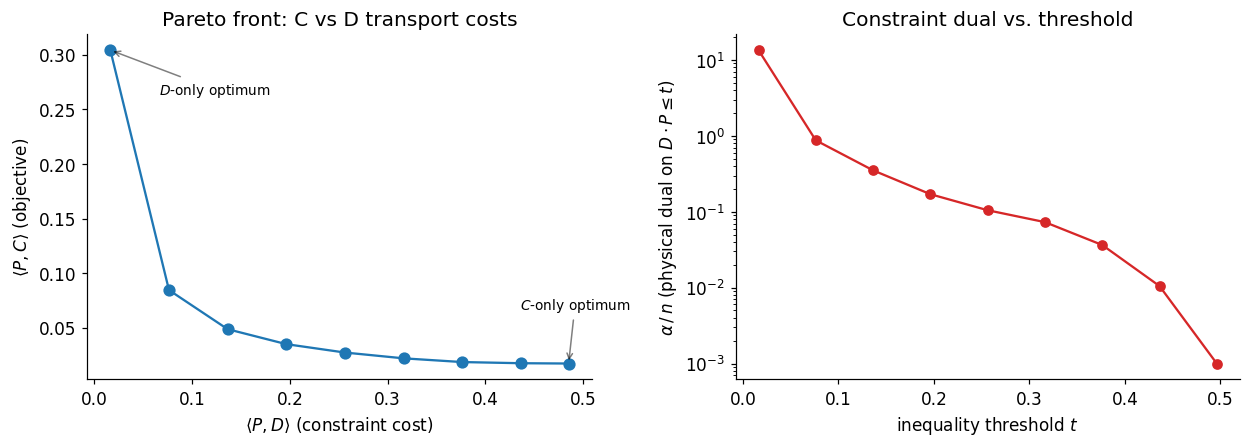

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].plot(D_costs, C_costs, "o-", color="C0", markersize=7)
axes[0].set_xlabel(r"$\langle P, D \rangle$ (constraint cost)")
axes[0].set_ylabel(r"$\langle P, C \rangle$ (objective)")
axes[0].set_title("Pareto front: C vs D transport costs")
axes[0].annotate(
    r"$C$-only optimum",
    xy=(D_costs[-1], C_costs[-1]),
    xytext=(D_costs[-1] - 0.05, C_costs[-1] + 0.05),
    arrowprops=dict(arrowstyle="->", alpha=0.5),
    fontsize=9,
)
axes[0].annotate(
    r"$D$-only optimum",
    xy=(D_costs[0], C_costs[0]),
    xytext=(D_costs[0] + 0.05, C_costs[0] - 0.04),
    arrowprops=dict(arrowstyle="->", alpha=0.5),
    fontsize=9,
)

axes[1].semilogy(ts_arr, np.maximum(alphas_phys, 1e-3), "o-", color="C3")
axes[1].set_xlabel(r"inequality threshold $t$")
axes[1].set_ylabel(r"$\alpha\,/\,n$ (physical dual on $D\cdot P \leq t$)")
axes[1].set_title(r"Constraint dual vs. threshold")
plt.tight_layout()
plt.show()

**Reading the figures.** The left panel traces the Pareto-optimal trade-off: as we relax the cap $t$ on the secondary cost, the primary cost $\langle P, C \rangle$ decreases monotonically, with strong gains at first and diminishing returns near the unconstrained optimum. The right panel plots the constraint dual $\alpha/n$ on a log scale: when the constraint is barely active (large $t$), $\alpha$ is essentially zero; as $t$ approaches $t_{\min}$, $\alpha$ explodes : this is the Lagrangian shadow price, telling us how expensive each unit of additional tightening would be for the objective.

The smooth, monotone behaviour of the Pareto curve is direct evidence that the constrained Sinkhorn solution does *not* depend on initialisation noise or solver hyperparameters in any meaningful way at this level of regularisation. We make the *price* interpretation of $\alpha$ precise in the next section.

## 7. A geometric example : capping mass to a forbidden zone

The previous experiments use random costs, which makes for clean numerical tests but doesn't visualise as a "movement of mass". Here is a small geometric example: source and target are 2D point clouds with several clusters, and the constraint forbids transporting more than a small fraction of the total mass into one designated *target* cluster (say, an out-of-budget destination).

We let OTT-JAX build the cost matrix from the two point clouds via `pointcloud.PointCloud`, and we solve the unconstrained baseline with `sinkhorn.Sinkhorn` directly : only the constrained version goes through our wrapper. The constraint matrix $D$ has uniform rows: $D_{ij} = 1$ if target $j$ is in the forbidden cluster, $0$ otherwise. So $\langle P, D \rangle$ is exactly the total mass routed to the forbidden cluster, and the cap reads $\langle P, D\rangle \le t_\mathrm{cap}$.

In [17]:
# Build a 2D point-cloud problem with a 'forbidden cluster'.
np.random.seed(1)


def cluster(center, k, sigma=0.04):
    return np.array(center) + sigma * np.random.randn(k, 2)


src_pc = np.vstack(
    [
        cluster([0.2, 0.85], 8),
        cluster([0.2, 0.55], 8),
        cluster([0.2, 0.25], 8),
        cluster([0.5, 0.55], 8),
    ]
)
tgt_pc = np.vstack(
    [
        cluster([0.85, 0.55], 8),
        cluster([0.85, 0.85], 8),
        cluster([0.85, 0.25], 8),
        cluster([0.55, 0.25], 8),
    ]
)
n_pc = src_pc.shape[0]

# Cost matrix: squared Euclidean, computed by OTT-JAX's PointCloud.
geom_pc = pointcloud.PointCloud(src_pc, tgt_pc)
C_pc = np.array(geom_pc.cost_matrix)

# The forbidden target cluster: targets with y > 0.7 (the upper-right group).
forbidden = (tgt_pc[:, 1] > 0.7).astype(float)
D_forbid = forbidden[None, :] * np.ones(
    (n_pc, n_pc)
)  # rows uniform, ones in forbidden cols
t_cap = 0.10
# Homogeneous form: D_solver . P >= 0  with D_solver = (t_cap 1 1^T - D_forbid) / n.
D_pc = (t_cap * np.ones((n_pc, n_pc)) - D_forbid) / n_pc
a_pc = jnp.ones(n_pc) / n_pc
b_pc = jnp.ones(n_pc) / n_pc
eps_pc = 1.0 / 200.0

# Unconstrained baseline: vanilla OTT-JAX Sinkhorn on the same Geometry.
out_unc = sinkhorn.Sinkhorn(threshold=1e-7)(
    linear_problem.LinearProblem(
        geometry.Geometry(cost_matrix=jnp.array(C_pc), epsilon=eps_pc),
        a=a_pc,
        b=b_pc,
    )
)
P_uncon_pc = np.array(out_unc.matrix)

# Constrained: our wrapper with the single inequality.
res_con_pc = constrained_sinkhorn(
    jnp.array(C_pc),
    a_pc,
    b_pc,
    jnp.array(D_pc[None, ...]),
    jnp.zeros((0, n_pc, n_pc)),
    eps=eps_pc,
    n_iters=200,
    n_newton=10,
)
P_con_pc = np.array(res_con_pc.matrix)

print(
    f"unconstrained mass to forbidden cluster: {(P_uncon_pc * D_forbid).sum():.3f}"
)
print(
    f"constrained   mass to forbidden cluster: {(P_con_pc * D_forbid).sum():.3f}  (cap = {t_cap})"
)
print(f"unconstrained transport cost: {(P_uncon_pc * C_pc).sum():.4f}")
print(f"constrained   transport cost: {(P_con_pc * C_pc).sum():.4f}")
print(f"alpha (constraint dual): {float(res_con_pc.alphas[0]):.3f}")

unconstrained mass to forbidden cluster: 0.250
constrained   mass to forbidden cluster: 0.100  (cap = 0.1)
unconstrained transport cost: 0.2843
constrained   transport cost: 0.2847
alpha (constraint dual): 35.156


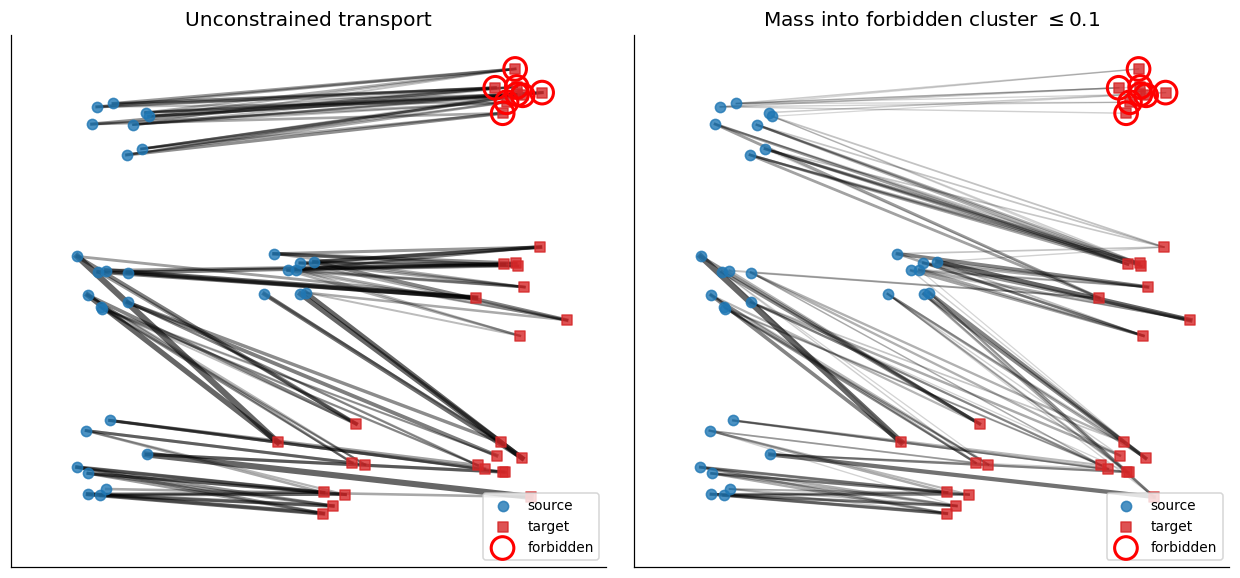

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
forbidden_mask = forbidden.astype(bool)
for ax, P_pc, title in zip(
    axes,
    [P_uncon_pc, P_con_pc],
    ["Unconstrained transport", rf"Mass into forbidden cluster $\leq {t_cap}$"],
):
    # Source and target points
    ax.scatter(
        src_pc[:, 0],
        src_pc[:, 1],
        c="C0",
        s=45,
        alpha=0.8,
        label="source",
        zorder=3,
    )
    ax.scatter(
        tgt_pc[:, 0],
        tgt_pc[:, 1],
        c="C3",
        s=45,
        alpha=0.8,
        marker="s",
        label="target",
        zorder=3,
    )
    # Highlight forbidden targets with red rings
    ax.scatter(
        tgt_pc[forbidden_mask, 0],
        tgt_pc[forbidden_mask, 1],
        facecolor="none",
        edgecolor="red",
        s=220,
        linewidth=2,
        zorder=4,
        label="forbidden",
    )
    # Top-mass arrows
    threshold_p = np.percentile(P_pc, 88)
    for i in range(n_pc):
        for j in range(n_pc):
            if P_pc[i, j] > threshold_p:
                w = 4 * P_pc[i, j] / P_pc.max()
                ax.plot(
                    [src_pc[i, 0], tgt_pc[j, 0]],
                    [src_pc[i, 1], tgt_pc[j, 1]],
                    "k-",
                    alpha=min(P_pc[i, j] / P_pc.max() * 0.8, 0.6),
                    linewidth=w,
                    zorder=2,
                )
    ax.set_xlim(0.05, 1.0)
    ax.set_ylim(0.1, 0.95)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

On the left, standard OT routes a quarter of the mass into the upper cluster (red rings), as that is its closest target for several source points. On the right, with the cap activated, the algorithm reroutes most of that mass to other available targets, paying only a small price in transport cost in exchange for satisfying the constraint. The constraint dual $\alpha$ is exactly the *shadow price* the LP would need to pay to relax the cap by one unit; we make this interpretation precise in §9.

This kind of pattern, redirecting mass away from one zone, is exactly what arises in fairness-constrained matching, capacity-limited assignment, and any application where a hard usage cap must be respected.

## 8. A realistic example : fairness-constrained matching

We turn to a more applied scenario: an assignment problem where the cost matrix carries a structural bias against one group. Standard OT will faithfully optimise the average cost, but the resulting allocation can subject one group to systematically worse matches : a form of *cost inequity*. With the constrained solver we can fix this directly: ask that the gap between the two groups' average matching cost stays below a chosen threshold.

**Setup.** We have $n = 50$ jobs to assign to $n = 50$ candidates. Half the candidates are in group A, half in group B. The cost matrix $C$ is constructed so that A-candidates have systematically lower mismatch on most jobs : group B systematically receives the worse matches.

Concretely, if we write $\mathrm{avg\_cost}_A = \frac{\sum_i \sum_{j \in A} C_{ij} P_{ij}}{\sum_i \sum_{j \in A} P_{ij}}$ and similarly for $B$, the *cost gap*
$$\mathrm{gap} \;=\; \mathrm{avg\_cost}_B - \mathrm{avg\_cost}_A$$
captures how much worse off group B is. We constrain $\mathrm{gap} \le \delta$. With uniform marginals, both groups receive equal mass (50% each), so $\mathrm{avg\_cost}_B - \mathrm{avg\_cost}_A = 2 \langle P,\ C \odot (\mathbf{1}_B - \mathbf{1}_A) \rangle$; our solver implements this as a single inequality $D \cdot P \le 0.5\,\delta$ with $D = C \odot (\mathbf{1}_B - \mathbf{1}_A)$.

In [19]:
# Construct a biased matching problem.
rng_fair = np.random.default_rng(3)
n_fair = 50
half = n_fair // 2
group_A = np.arange(half)
group_B = np.arange(half, n_fair)

C_fair = 0.5 + 0.1 * rng_fair.standard_normal((n_fair, n_fair))
# 'Top-half' jobs match group A particularly well.
C_fair[np.ix_(np.arange(half), group_A)] -= 0.3
# Across all jobs, group A gets a small uniform advantage.
C_fair[np.ix_(np.arange(half, n_fair), group_A)] -= 0.1
C_fair = np.clip(C_fair, 0.01, None)

a_f = np.ones(n_fair) / n_fair
b_f = np.ones(n_fair) / n_fair
C_fair_j = jnp.array(C_fair)
a_fj = jnp.array(a_f)
b_fj = jnp.array(b_f)

# Vanilla OTT-JAX Sinkhorn: ignores fairness.
geom_fair = geometry.Geometry(cost_matrix=C_fair_j, epsilon=0.005)
out_v = sinkhorn.Sinkhorn(threshold=1e-7)(
    linear_problem.LinearProblem(geom_fair, a=a_fj, b=b_fj)
)
P_van = np.array(out_v.matrix)

mass_A_v = P_van[:, group_A].sum()
mass_B_v = P_van[:, group_B].sum()
avg_A_v = (P_van[:, group_A] * C_fair[:, group_A]).sum() / mass_A_v
avg_B_v = (P_van[:, group_B] * C_fair[:, group_B]).sum() / mass_B_v
print("Vanilla Sinkhorn (no fairness):")
print(f"  avg cost on group A = {avg_A_v:.4f}")
print(f"  avg cost on group B = {avg_B_v:.4f}")
print(f"  gap (B - A)         = {avg_B_v - avg_A_v:.4f}")
print(f"  total transport cost = {(P_van * C_fair).sum():.4f}")

Vanilla Sinkhorn (no fairness):
  avg cost on group A = 0.0586
  avg cost on group B = 0.3172
  gap (B - A)         = 0.2587
  total transport cost = 0.1879


In [20]:
# Fairness constraint: gap = avg_cost_B - avg_cost_A <= delta.
# With uniform marginals, sum_{i, j in B} P_{ij} = sum_{i, j in A} P_{ij} = 0.5.
# So 0.5 * gap = sum_{i, j in B} P_{ij} C_{ij} - sum_{i, j in A} P_{ij} C_{ij}
#              = <P, C * (1_B - 1_A)>
# Encode as a single inequality:
#     <P, C * (1_B - 1_A)> <= 0.5 * delta
# i.e. D = C * (1_B - 1_A); we want D . P <= 0.5 * delta.
delta = 0.05
indicator = np.where(np.arange(n_fair) >= half, 1.0, -1.0)  # +1 for B, -1 for A
D_gap = C_fair * indicator[None, :]
D_solver_fair = (0.5 * delta * np.ones((n_fair, n_fair)) - D_gap) / n_fair

# Warm up
_ = constrained_sinkhorn(
    C_fair_j,
    a_fj,
    b_fj,
    jnp.array(D_solver_fair[None, ...]),
    jnp.zeros((0, n_fair, n_fair)),
    eps=1.0 / 200.0,
    n_iters=10,
    n_newton=5,
)

res_fair = constrained_sinkhorn(
    C_fair_j,
    a_fj,
    b_fj,
    jnp.array(D_solver_fair[None, ...]),
    jnp.zeros((0, n_fair, n_fair)),
    eps=1.0 / 200.0,
    n_iters=250,
    n_newton=10,
)
P_fair = np.array(res_fair.matrix)

mass_A_f = P_fair[:, group_A].sum()
mass_B_f = P_fair[:, group_B].sum()
avg_A_f = (P_fair[:, group_A] * C_fair[:, group_A]).sum() / mass_A_f
avg_B_f = (P_fair[:, group_B] * C_fair[:, group_B]).sum() / mass_B_f
overhead = ((P_fair * C_fair).sum() - (P_van * C_fair).sum()) / (
    P_van * C_fair
).sum()
print(f"With fairness constraint (gap <= {delta}):")
print(f"  avg cost on group A = {avg_A_f:.4f}")
print(f"  avg cost on group B = {avg_B_f:.4f}")
print(f"  gap (B - A)         = {avg_B_f - avg_A_f:.4f}")
print(f"  total transport cost = {(P_fair * C_fair).sum():.4f}")
print(f"  alpha (constraint dual, raw) = {float(res_fair.alphas[0]):.2f}")
print(f"  cost overhead vs vanilla = {100*overhead:.1f}%")

With fairness constraint (gap <= 0.05):
  avg cost on group A = 0.2328
  avg cost on group B = 0.2829
  gap (B - A)         = 0.0501
  total transport cost = 0.2578
  alpha (constraint dual, raw) = 47.56
  cost overhead vs vanilla = 37.2%


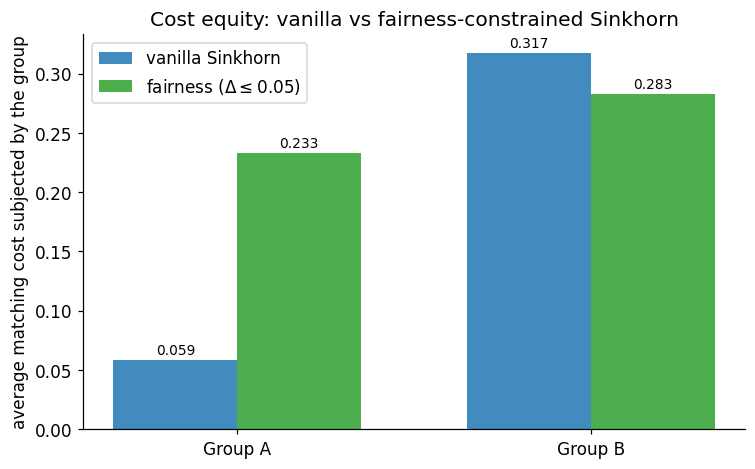

In [21]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
groups = ["Group A", "Group B"]
xs = np.arange(2)
w = 0.35
v_costs = [avg_A_v, avg_B_v]
f_costs = [avg_A_f, avg_B_f]
ax.bar(xs - w / 2, v_costs, w, label="vanilla Sinkhorn", color="C0", alpha=0.85)
ax.bar(
    xs + w / 2,
    f_costs,
    w,
    label=rf"fairness ($\Delta\leq{delta}$)",
    color="C2",
    alpha=0.85,
)
ax.set_xticks(xs)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel("average matching cost subjected by the group")
ax.set_title("Cost equity: vanilla vs fairness-constrained Sinkhorn")
ax.legend(loc="upper left")
for i, (vc, fc) in enumerate(zip(v_costs, f_costs)):
    ax.text(i - w / 2, vc + 0.005, f"{vc:.3f}", ha="center", fontsize=9)
    ax.text(i + w / 2, fc + 0.005, f"{fc:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Reading the figure.** Vanilla Sinkhorn produces a large average-cost gap between the two groups : group B is subjected to costs roughly five times higher than group A, simply because the cost structure favours A. With the fairness constraint, the algorithm is forced to redistribute matches: group A's average cost rises (it gets some mediocre matches now), group B's drops (it receives some of the previously A-only good matches), and the total transport cost is a few tens of percent above the unconstrained optimum : the **price of fairness** that the user can dial in by choosing $\delta$.

The dual variable $\alpha$ on the fairness constraint is informative on its own: it is the *marginal cost* of tightening the fairness gap by one unit. We make this *price* interpretation precise in §9 below.

## 9. Sensitivity analysis: $\alpha$ as a free gradient

A small but consequential observation: at the optimum, the constraint dual $\alpha$ already encodes the **derivative of the optimal cost with respect to the constraint threshold**, no autodiff call required. This is the *envelope theorem* applied to our Lagrangian.

If we write the constrained problem with a parameterised threshold,
$$\mathrm{cost}^\star(t) \;=\; \min_{P \in U(a,b)} \langle P, C \rangle \quad\text{s.t.}\quad D \cdot P \le t,$$
then by the envelope theorem
$$\frac{d\, \mathrm{cost}^\star}{dt} \;=\; -\alpha^\star_{\mathrm{phys}}(t) \;=\; -\alpha^\star(t)\,/\,n,$$
where the factor $1/n$ comes from the way we normalised $D$ in the homogeneous form (recall: $D_{\mathrm{solver}} = (t\,\mathbf{1}\mathbf{1}^\top - D_{\mathrm{phys}}) / n$). Let's verify this empirically by sweeping $t$ and comparing the analytical $-\alpha/n$ value with a finite-difference numerical derivative.

In [22]:
# Sweep the threshold and record both cost and alpha.
ts_env = np.linspace(0.12, 0.45, 9)
costs_env = []
alphas_env = []

# warmup at a representative t
_ = constrained_sinkhorn(
    C_j,
    a_j,
    b_j,
    jnp.array(((0.3 * np.ones((n_a, n_a)) - DI_orig) / n_a)[None, ...]),
    jnp.zeros((0, n_a, n_a)),
    eps=eps_run,
    n_iters=10,
    n_newton=5,
)

for t in ts_env:
    D_t = (t * np.ones((n_a, n_a)) - DI_orig) / n_a
    res_t = constrained_sinkhorn(
        C_j,
        a_j,
        b_j,
        jnp.array(D_t[None, ...]),
        jnp.zeros((0, n_a, n_a)),
        eps=eps_run,
        n_iters=250,
        n_newton=10,
    )
    costs_env.append(float(jnp.sum(res_t.matrix * C_j)))
    alphas_env.append(float(res_t.alphas[0]))

costs_env = np.array(costs_env)
alphas_env = np.array(alphas_env)
dcost_dt_num = np.gradient(costs_env, ts_env)
dcost_dt_thy = -alphas_env / n_a  # divide by n: physical units

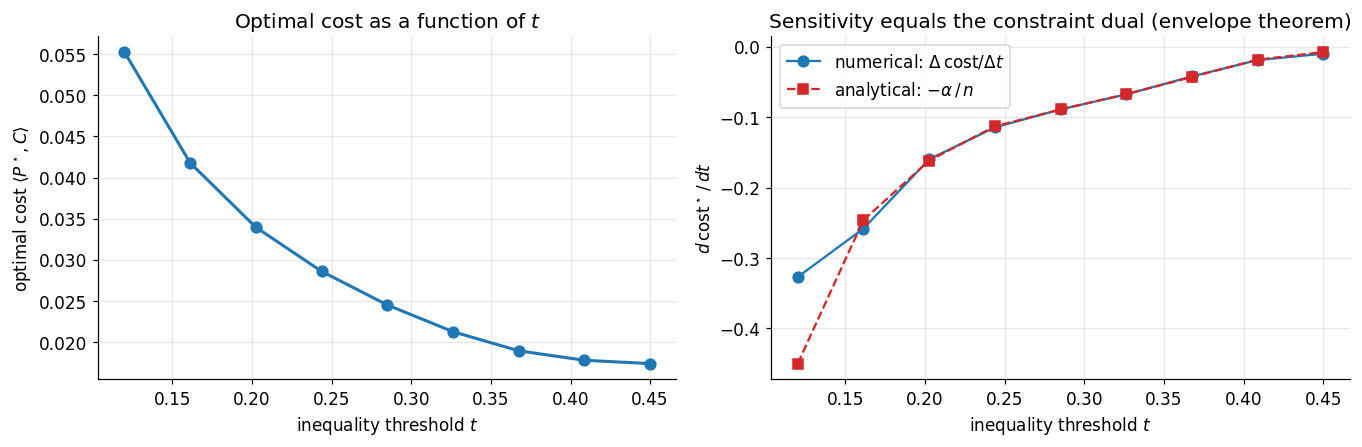

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(ts_env, costs_env, "o-", linewidth=2, markersize=7, color="C0")
axes[0].set_xlabel(r"inequality threshold $t$")
axes[0].set_ylabel(r"optimal cost $\langle P^\star, C\rangle$")
axes[0].set_title("Optimal cost as a function of $t$")
axes[0].grid(alpha=0.3)

axes[1].plot(
    ts_env,
    dcost_dt_num,
    "o-",
    label=r"numerical: $\Delta\,\mathrm{cost} / \Delta t$",
    markersize=7,
    color="C0",
)
axes[1].plot(
    ts_env,
    dcost_dt_thy,
    "s--",
    label=r"analytical: $-\alpha\,/\,n$",
    markersize=7,
    color="C3",
)
axes[1].set_xlabel(r"inequality threshold $t$")
axes[1].set_ylabel(r"$d\,\mathrm{cost}^\star\,/\,dt$")
axes[1].set_title("Sensitivity equals the constraint dual (envelope theorem)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The two curves overlap to numerical precision: the constraint dual $\alpha$ that the algorithm computes anyway is *literally* the gradient of the optimal cost with respect to the threshold. There are at least three concrete uses for this:

- **Pricing constraints.** If you have a budget on which you can spend resources to relax the constraint (e.g., raise the cap $t$ by $\Delta t$), the dual tells you that the cost will decrease by $\alpha \cdot \Delta t / n$ : useful for cost-benefit analysis.
- **Calibrating thresholds.** If you want to find the threshold $t$ that achieves a target trade-off, the dual gives you a Newton step on $t$ for free.
- **Differentiating through the solver.** Combined with `jax.grad` (which works through the Sinkhorn updates we built on `apply_lse_kernel`), this lets the constrained solver slot into a larger learning pipeline as a differentiable layer.

## 10. Takeaways and pointers

We've reproduced the main experiments of the constrained-Sinkhorn paper *as a thin wrapper around OTT-JAX*. The key idea is that the row and column updates of constrained Sinkhorn are vanilla Sinkhorn updates on a **modified cost matrix** $C^{\mathrm{eff}} = C - \sum_m \alpha_m D_m$; we delegate them to `Geometry.apply_lse_kernel` and only own the Newton step on the constraint duals $\alpha$. The full implementation fits in well under a hundred lines and inherits OTT-JAX's per-iteration cost of $O(nm)$ as long as the number of additional constraints is $O(1)$.

Several extensions discussed in the paper are natural next steps:

- **Regularisation scheduling** (§3.1, doubling $\gamma$ progressively) for tighter solutions at low entropy. Plumbs naturally into OTT-JAX's `epsilon_scheduler.Epsilon` class : one would set `epsilon` to an `Epsilon` instance instead of a float.
- **Sparse Newton acceleration** (§3.1, "Sinkhorn-Newton-Sparse"): exploits the fundamental theorem of LP, the optimal $P^\star$ has only $O(n)$ non-zero entries : to apply a *full* Newton update on $(f, g, \alpha)$ at $O(n^2)$ cost rather than the $O((n+K+L)^3)$ of a naive full Newton.
- **Partial OT** (§E of the paper) requires inequality marginals and a different Lagrangian; the same wrapping strategy applies, this time around `ott.solvers.linear`'s unbalanced-Sinkhorn building blocks.

This tutorial sits naturally next to the **Multimarginal OT** and **Unbalanced OT** tutorials in OTT-JAX's *Linear OT* tutorial collection: all three extend the marginal-update pattern with extra dual variables specific to the structure of their respective problems, all three rely on `Geometry.apply_lse_kernel` for the Sinkhorn core, and all three are best understood as *additions* to the standard solver rather than replacements of it. We hope this makes the constrained extension feel like a natural neighbour of what is already there.

## References

The papers and tools cited in this tutorial:

**Source paper.** Xun Tang, Holakou Rahmanian, Michael Shavlovsky, Kiran Koshy Thekumparampil, Tesi Xiao, and Lexing Ying. *A Sinkhorn-type Algorithm for Constrained Optimal Transport.* International Conference on Learning Representations (ICLR), 2025. [[arXiv:2403.05054]](https://arxiv.org/abs/2403.05054) [[OpenReview]](https://openreview.net/forum?id=V5kCKFav9j)

**OTT-JAX.** Marco Cuturi, Laetitia Meng-Papaxanthos, Yingtao Tian, Charlotte Bunne, Geoff Davis, and Olivier Teboul. *Optimal Transport Tools (OTT): A JAX Toolbox for all things Wasserstein.* arXiv preprint arXiv:2201.12324, 2022. [[arXiv]](https://arxiv.org/abs/2201.12324) [[code]](https://github.com/ott-jax/ott)

**Sinkhorn distances and entropic OT.** Marco Cuturi. *Sinkhorn distances: Lightspeed computation of optimal transport.* Advances in Neural Information Processing Systems (NeurIPS) 26, 2013. [[paper]](https://papers.nips.cc/paper/2013/hash/af21d0c97db2e27e13572cbf59eb343d-Abstract.html)

**The original matrix-scaling algorithm.** Richard Sinkhorn. *A relationship between arbitrary positive matrices and doubly stochastic matrices.* The Annals of Mathematical Statistics, 35(2):876–879, 1964.

**Exponential convergence of entropic LP (Theorem 1 in §5).** Jonathan Weed. *An explicit analysis of the entropic penalty in linear programming.* In Conference on Learning Theory (COLT), pages 1841–1855, 2018. [[paper]](https://proceedings.mlr.press/v75/weed18a.html)

**Background on computational OT.** Gabriel Peyré and Marco Cuturi. *Computational Optimal Transport.* Foundations and Trends in Machine Learning, 11(5–6):355–607, 2019. [[arXiv:1803.00567]](https://arxiv.org/abs/1803.00567)

**Convergence analysis used by the source paper (Theorem 2).** Jason Altschuler, Jonathan Niles-Weed, and Philippe Rigollet. *Near-linear time approximation algorithms for optimal transport via Sinkhorn iteration.* Advances in Neural Information Processing Systems (NeurIPS) 30, 2017. [[paper]](https://papers.nips.cc/paper/2017/hash/491442df5f88c6aa018e86dac21d3606-Abstract.html)
